In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
nav = pd.read_csv("Data/Processed/02_nav_history_clean.csv")
transactions = pd.read_csv("Data/Processed/08_investor_transactions_clean.csv")
portfolio = pd.read_csv("Data/Processed/09_portfolio_holdings_clean.csv")
performance = pd.read_csv("Data/Processed/07_scheme_performance_clean.csv")

In [8]:
nav['date'] = pd.to_datetime(nav['date'])

In [10]:
nav = nav.sort_values(['amfi_code','date'])

nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
       .pct_change()
)

In [11]:
results = []

for fund in nav['amfi_code'].unique():

    r = nav[
        nav['amfi_code']==fund
    ]['daily_return'].dropna()

    var95 = np.percentile(r,5)

    cvar95 = r[r <= var95].mean()

    results.append([
        fund,
        var95,
        cvar95
    ])

var_df = pd.DataFrame(
    results,
    columns=[
        'amfi_code',
        'VaR_95',
        'CVaR_95'
    ]
)

In [12]:
var_df.to_csv(
    "var_cvar_report.csv",
    index=False
)

In [13]:
top5 = nav['amfi_code'].unique()[:5]

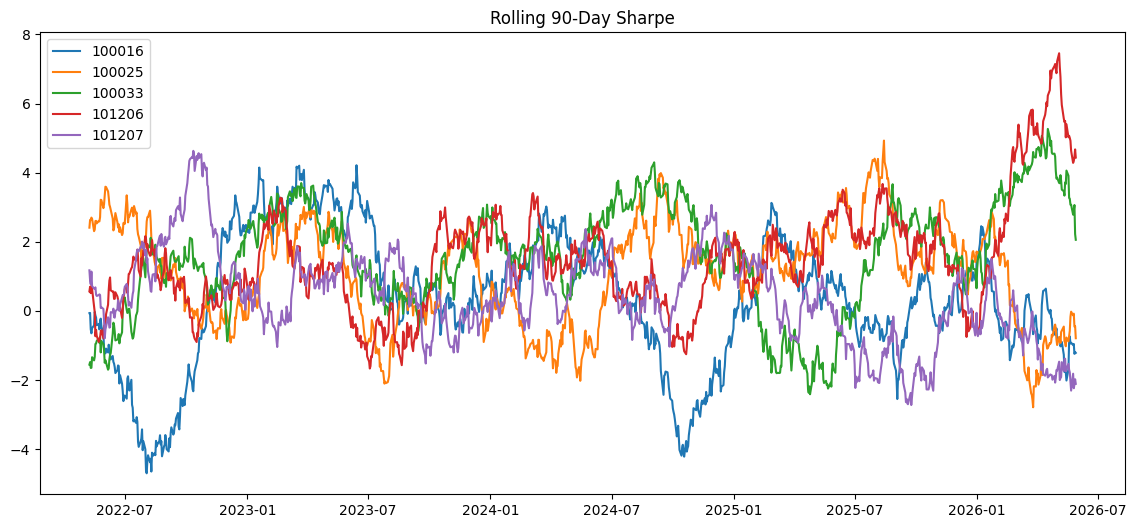

In [14]:
plt.figure(figsize=(14,6))

for fund in top5:

    temp = nav[
        nav['amfi_code']==fund
    ].copy()

    rolling_sharpe = (
        temp['daily_return']
        .rolling(90)
        .mean()
        /
        temp['daily_return']
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        temp['date'],
        rolling_sharpe,
        label=str(fund)
    )

plt.legend()
plt.title("Rolling 90-Day Sharpe")
plt.show()

In [15]:
plt.savefig(
    "rolling_sharpe_chart.png"
)

<Figure size 640x480 with 0 Axes>

In [16]:
transactions['transaction_date'] = pd.to_datetime(
    transactions['transaction_date']
)

first_txn = (
    transactions
    .groupby('investor_id')
    ['transaction_date']
    .min()
)

cohort = first_txn.dt.year

In [17]:
transactions['cohort_year'] = (
    transactions['investor_id']
    .map(cohort)
)

In [20]:
cohort_summary = (
    transactions
    .groupby('cohort_year')['amount_inr']
    .agg(['mean', 'sum'])
)

print(cohort_summary)

                      mean         sum
cohort_year                           
2024         107422.541832  3491125187
2025         109158.577061    30455243


In [21]:
sip = transactions[
    transactions['transaction_type']
    == 'SIP'
]

In [22]:
sip = sip.sort_values(
    ['investor_id','transaction_date']
)

sip['gap_days'] = (
    sip.groupby('investor_id')
    ['transaction_date']
    .diff()
    .dt.days
)

In [23]:
risk = (
    sip.groupby('investor_id')
    ['gap_days']
    .mean()
)

at_risk = risk[
    risk > 35
]

In [24]:
len(at_risk)

3825

In [31]:
scorecard['risk_grade'] = 'Moderate'

scorecard.loc[
    (scorecard['beta_calc'] < 0.8) &
    (scorecard['max_drawdown_calc'] > -15),
    'risk_grade'
] = 'Low'

scorecard.loc[
    (scorecard['beta_calc'] > 1.1) |
    (scorecard['max_drawdown_calc'] < -25),
    'risk_grade'
] = 'High'

In [32]:
recommend = scorecard[
    scorecard['risk_grade'] == grade
]

In [33]:
print(scorecard['risk_grade'].value_counts())

risk_grade
Low         27
High        10
Moderate     3
Name: count, dtype: int64


In [34]:
scorecard['risk_grade'] == grade

0      True
1      True
2     False
3     False
4      True
5      True
6      True
7     False
8      True
9     False
10    False
11     True
12     True
13     True
14     True
15     True
16     True
17    False
18    False
19     True
20    False
21    False
22    False
23     True
24     True
25     True
26     True
27     True
28     True
29    False
30     True
31     True
32     True
33     True
34     True
35    False
36     True
37     True
38     True
39    False
Name: risk_grade, dtype: bool

In [35]:
print(grade)

Low


In [36]:
recommend = scorecard[
    scorecard['risk_grade'] == grade
]

print(recommend.shape)
recommend.head()

(27, 22)


,amfi_code,cagr,cagr_pct,sharpe_ratio_calc,sortino_ratio_calc,max_drawdown_calc,alpha_calc,beta_calc,return_3yr_pct,expense_ratio_pct,...,rank_alpha,rank_expense,rank_3yr_score,rank_sharpe_score,rank_alpha_score,rank_expense_score,rank_drawdown,rank_drawdown_score,fund_score,risk_grade
0,120505,0.328016,32.80,1.513677,2.602985,-0.181885,29.508521,-1.745379,18.08,1.36,...,3.0,15.0,82.5,80.0,95.0,65.0,25.0,40.0,77.500,Low
1,120843,0.308833,30.88,1.711792,3.097183,-0.129740,27.321126,-0.436989,15.65,1.45,...,5.0,22.0,75.0,90.0,90.0,47.5,13.0,70.0,77.125,Low
4,119598,0.323981,32.40,1.201269,2.128941,-0.287060,30.314487,-0.350801,23.39,1.43,...,1.0,21.0,100.0,45.0,100.0,50.0,36.0,12.5,70.000,Low
5,120504,0.232774,23.28,1.474526,2.593171,-0.125883,21.609065,-2.613923,14.41,0.80,...,11.0,12.0,52.5,75.0,75.0,72.5,12.0,72.5,67.625,Low
6,149323,0.295581,29.56,1.494736,2.475688,-0.172481,26.573262,0.125950,17.16,1.61,...,8.0,38.0,80.0,77.5,82.5,7.5,22.0,47.5,65.750,Low


In [37]:
scorecard.groupby('risk_grade').size()

risk_grade
High        10
Low         27
Moderate     3
dtype: int64

In [38]:
print(grade)
print(scorecard['risk_grade'].value_counts())

Low
risk_grade
Low         27
High        10
Moderate     3
Name: count, dtype: int64


In [39]:
top_funds = (
    scorecard[scorecard['risk_grade'] == grade]
    .sort_values('fund_score', ascending=False)
    .head(5)
)

print(top_funds[['amfi_code','fund_score','risk_grade']])

   amfi_code  fund_score risk_grade
0     120505      77.500        Low
1     120843      77.125        Low
4     119598      70.000        Low
5     120504      67.625        Low
6     149323      65.750        Low


In [40]:
risk = input("Risk Appetite (Low/Moderate/High): ")

mapping = {
    "Low": "Low",
    "Moderate": "Moderate",
    "High": "High"
}

grade = mapping[risk]

recommend = (
    scorecard[scorecard['risk_grade'] == grade]
    .sort_values('fund_score', ascending=False)
    .head(5)
)

recommend[['amfi_code', 'fund_score', 'risk_grade']]

Risk Appetite (Low/Moderate/High):  Low


,amfi_code,fund_score,risk_grade
0,120505,77.500,Low
1,120843,77.125,Low
4,119598,70.000,Low
5,120504,67.625,Low
6,149323,65.750,Low


In [41]:
hhi = (
    portfolio
    .groupby('amfi_code')
    ['weight_pct']
    .apply(
        lambda x:
        (x/100).pow(2).sum()
    )
)

In [42]:
hhi = hhi.reset_index()

hhi.columns = [
    'amfi_code',
    'HHI'
]

In [43]:
hhi.head(10)

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709
5,102886,0.114693
6,102887,0.129805
7,118632,0.168298
8,118633,0.121461
9,118634,0.108358


In [44]:
hhi.sort_values(
    'HHI',
    ascending=False
).head(10)

,amfi_code,HHI
11,119092,0.206448
3,101207,0.200700
18,119599,0.174751
4,102885,0.174709
7,118632,0.168298
29,148568,0.167930
21,120505,0.157570
22,120506,0.153794
27,125498,0.152414
23,120841,0.149680


In [45]:
hhi.to_csv(
    "sector_hhi_report.csv",
    index=False
)

In [46]:
import os

os.path.exists(
    "sector_hhi_report.csv"
)

True

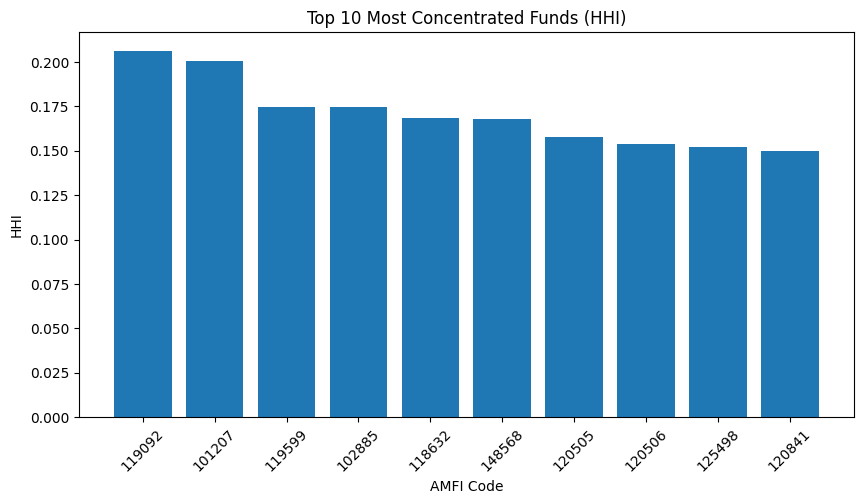

In [47]:
import matplotlib.pyplot as plt

top_hhi = hhi.sort_values(
    'HHI',
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top_hhi['amfi_code'].astype(str),
    top_hhi['HHI']
)

plt.title("Top 10 Most Concentrated Funds (HHI)")
plt.xlabel("AMFI Code")
plt.ylabel("HHI")

plt.xticks(rotation=45)

plt.show()

In [48]:
hhi.sort_values('HHI', ascending=False).head()

,amfi_code,HHI
11,119092,0.206448
3,101207,0.200700
18,119599,0.174751
4,102885,0.174709
7,118632,0.168298


In [50]:
hhi.to_csv(
    "sector_hhi_report.csv",
    index=False
)

print("sector_hhi_report.csv saved")

sector_hhi_report.csv saved


In [51]:
import os

for f in os.listdir():
    print(f)

.git
.ipynb_checkpoints
Advanced_Analytics.ipynb
alpha_beta.csv
anaconda_projects
benchmark_comparison.png
bluestock_mf_dashboard.pbix
cagr_table.csv
Dashboard
Data
data_ingestion.py
fund_scorecard.csv
live_nav_fetch.py
mutual fund dashboard.pbix
mutual_fund.db
Notebooks
README.md
Reports
requirements.txt
rolling_sharpe_chart.png
scorecard.csv
sector_hhi_report.csv
sharpe_ratio.csv
SQL
var_cvar_report.csv
